# Predykcja Odejść Klientów Telco - Metody Analizy Danych Projekt 2

**Autorzy:** Filip Michalak, Jakub Michalski, Marek Najmóła  
**Data:** 09.06.2026

## Abstrakt

Celem niniejszej pracy jest predykcja odejść klientów firmy telekomunikacyjnej (Telco) przy użyciu czterech metod klasyfikacji: regresji logistycznej, drzewa decyzyjnego, lasu losowego oraz XGBoost, a także modelu hybrydowego. Analizę przeprowadzono na zbiorze 7043 klientów opisanych 21 zmiennymi. Wyniki wskazują na wysoką skuteczność regresji logistycznej (AUC = 0,842) oraz modelu hybrydowego (AUC = 0,841). Regresja logistyczna nieznacznie przewyższyła metody zespołowe - las losowy (AUC = 0,838) i XGBoost (AUC = 0,832). Model hybrydowy łączący wszystkie podejścia osiągnął konkurencyjne wyniki, potwierdzając wartość agregacji predykcji wielu modeli.

**Słowa kluczowe:** klasyfikacja, churn, regresja logistyczna, las losowy, XGBoost, Telco, model hybrydowy


## 1. Wprowadzenie

Retencja klientów jest kluczowym wyzwaniem w branży telekomunikacyjnej. Koszt pozyskania nowego klienta jest znacznie wyższy niż utrzymanie obecnego, według badań przemysłowych, pozyskanie nowego klienta może być nawet 5-25 razy droższe niż retencja istniejącego. Predykcja odejść (churn) pozwala firmom proaktywnie identyfikować klientów zagrożonych rezygnacją i podejmować działania retencyjne zanim dojdzie do faktycznego odejścia.

Współczesne metody uczenia maszynowego oferują zaawansowane narzędzia do analizy historycznych danych i budowy modeli predykcyjnych. W niniejszej pracy zastosowano cztery różne podejścia klasyfikacyjne, od prostego modelu regresji logistycznej po zaawansowane algorytmy zespołowe (Random Forest, XGBoost), a następnie połączono je w model hybrydowy.

**Cel pracy:** Zbudowanie i porównanie modeli klasyfikacyjnych predykcyjnych odejść klientów Telco przy użyciu czterech metod oraz modelu hybrydowego.

**Metody:**
1. **Regresja logistyczna** - klasyczna metoda klasyfikacji binarnej
2. **Drzewo decyzyjne** - interpretowalny model oparty na regułach if-then
3. **Las losowy (Random Forest)** - zespół drzew decyzyjnych
4. **XGBoost** - zaawansowany gradient boosting
5. **Model hybrydowy (Weighted Average)** - ważona średnia prawdopodobieństw


## 2. Przedmiot badania

### 2.1 Dane

Zbiór danych pochodzi z firmy telekomunikacyjnej Telco i zawiera informacje o 7043 klientach opisanych 21 zmiennymi (w tym 1 zmienna docelowa `Churn`). Dane zostały udostępnione przez IBM jako zbiór przykładowy i są powszechnie wykorzystywane w literaturze do benchmarkowania modeli predykcji churn.

**Podstawowe charakterystyki zbioru:**
- Liczba obserwacji: 7043
- Liczba zmiennych: 21 (w tym 1 identyfikator, 1 target)
- Zmienna docelowa: `Churn` (Yes/No)
- Rozkład klasy: 26,5% churn vs 73,5% retencja


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
import os
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja wizualna
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})
sns.set_style("whitegrid")

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Wczytanie danych
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Tabela: charakterystyka zbioru
summary_df = pd.DataFrame({
    "Metryka": ["Liczba wierszy", "Liczba kolumn"],
    "Wartosc": [df.shape[0], df.shape[1]],
})
display(HTML(summary_df.to_html(index=False, classes='table table-striped')))

# Tabela: typy zmiennych
types_df = pd.DataFrame({
    "Zmienna": df.columns,
    "Typ": df.dtypes.astype(str).values,
})
display(HTML(types_df.to_html(index=False, classes='table table-striped')))

# Tabela: braki danych
missing_df = df.isnull().sum()
missing_df = missing_df[missing_df > 0].reset_index()
missing_df.columns = ["Zmienna", "Braki"]
if missing_df.empty:
    missing_df = pd.DataFrame({"Zmienna": ["(brak)"], "Braki": [0]})
display(HTML(missing_df.to_html(index=False, classes='table table-striped')))

Metryka,Wartosc
Liczba wierszy,7043
Liczba kolumn,21


Zmienna,Typ
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


Zmienna,Braki
TotalCharges,11


### 2.2 Zmienne w zbiorze

Poniżej przedstawiono wszystkie zmienne w zbiorze danych wraz z ich typem, opisem i zakresem wartości.


In [28]:
# Tabela zmiennych
var_desc = [
    ('customerID', 'identyfikator', 'ID klienta'),
    ('gender', 'binarny', 'Płeć (Male/Female)'),
    ('SeniorCitizen', 'binarny', 'Senior (0/1)'),
    ('Partner', 'binarny', 'Partner (Yes/No)'),
    ('Dependents', 'binarny', 'Na utrzymaniu (Yes/No)'),
    ('tenure', 'ciągły', 'Staż klienta (miesiące)'),
    ('PhoneService', 'binarny', 'Usługa telefoniczna'),
    ('MultipleLines', 'kategorialny', 'Wiele linii'),
    ('InternetService', 'kategorialny', 'Usługa internetowa'),
    ('OnlineSecurity', 'kategorialny', 'Bezpieczeństwo online'),
    ('OnlineBackup', 'kategorialny', 'Kopie zapasowe online'),
    ('DeviceProtection', 'kategorialny', 'Ochrona urządzenia'),
    ('TechSupport', 'kategorialny', 'Wsparcie techniczne'),
    ('StreamingTV', 'kategorialny', 'Telewizja strumieniowa'),
    ('StreamingMovies', 'kategorialny', 'Filmy strumieniowe'),
    ('Contract', 'kategorialny', 'Rodzaj umowy'),
    ('PaperlessBilling', 'binarny', 'Fakturowanie elektroniczne'),
    ('PaymentMethod', 'kategorialny', 'Metoda płatności'),
    ('MonthlyCharges', 'ciągły', 'Miesięczna opłata ($)'),
    ('TotalCharges', 'ciągły', 'Łączna opłata ($)'),
    ('Churn', 'binarny', 'Odejście klienta (Yes/No)')
]
var_df = pd.DataFrame(var_desc, columns=['Zmienna', 'Typ', 'Opis'])
display(HTML(var_df.to_html(index=False, classes='table table-striped')))

Zmienna,Typ,Opis
customerID,identyfikator,ID klienta
gender,binarny,Płeć (Male/Female)
SeniorCitizen,binarny,Senior (0/1)
Partner,binarny,Partner (Yes/No)
Dependents,binarny,Na utrzymaniu (Yes/No)
tenure,ciągły,Staż klienta (miesiące)
PhoneService,binarny,Usługa telefoniczna
MultipleLines,kategorialny,Wiele linii
InternetService,kategorialny,Usługa internetowa
OnlineSecurity,kategorialny,Bezpieczeństwo online


### 2.3 Statystyki opisowe

#### 2.3.1 Zmienne numeryczne


In [29]:
# Statystyki numeryczne z dodatkowym wierszem skosnosci
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
stats_table = df[numeric_cols].describe().round(2)
from scipy import stats as sp_stats
stats_table.loc['skewness'] = [sp_stats.skew(df[c].dropna(), bias=False).round(4) for c in numeric_cols]
display(HTML(stats_table.to_html(classes='table table-striped')))

,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7032.0000
mean,32.3700,64.7600,2283.3000
std,24.5600,30.0900,2266.7700
min,0.0000,18.2500,18.8000
25%,9.0000,35.5000,401.4500
50%,29.0000,70.3500,1397.4800
75%,55.0000,89.8500,3794.7400
max,72.0000,118.7500,8684.8000
skewness,0.2395,-0.2205,0.9616


#### 2.3.2 Zmienne kategorialne


In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('customerID')

print("=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===")
for col in categorical_cols:
    print(f"{col}:")
    vc = df[col].value_counts()
    for val, cnt in vc.items():
        pct = cnt / len(df) * 100
        print(f"  {val}: {cnt} ({pct:.1f}%)")


=== ROZKŁAD ZMIENNYCH KATEGORIALNYCH ===
gender:
  Male: 3555 (50.5%)
  Female: 3488 (49.5%)
Partner:
  No: 3641 (51.7%)
  Yes: 3402 (48.3%)
Dependents:
  No: 4933 (70.0%)
  Yes: 2110 (30.0%)
PhoneService:
  Yes: 6361 (90.3%)
  No: 682 (9.7%)
MultipleLines:
  No: 3390 (48.1%)
  Yes: 2971 (42.2%)
  No phone service: 682 (9.7%)
InternetService:
  Fiber optic: 3096 (44.0%)
  DSL: 2421 (34.4%)
  No: 1526 (21.7%)
OnlineSecurity:
  No: 3498 (49.7%)
  Yes: 2019 (28.7%)
  No internet service: 1526 (21.7%)
OnlineBackup:
  No: 3088 (43.8%)
  Yes: 2429 (34.5%)
  No internet service: 1526 (21.7%)
DeviceProtection:
  No: 3095 (43.9%)
  Yes: 2422 (34.4%)
  No internet service: 1526 (21.7%)
TechSupport:
  No: 3473 (49.3%)
  Yes: 2044 (29.0%)
  No internet service: 1526 (21.7%)
StreamingTV:
  No: 2810 (39.9%)
  Yes: 2707 (38.4%)
  No internet service: 1526 (21.7%)
StreamingMovies:
  No: 2785 (39.5%)
  Yes: 2732 (38.8%)
  No internet service: 1526 (21.7%)
Contract:
  Month-to-month: 3875 (55.0%)
  Two 

### 2.4 Wizualizacje danych


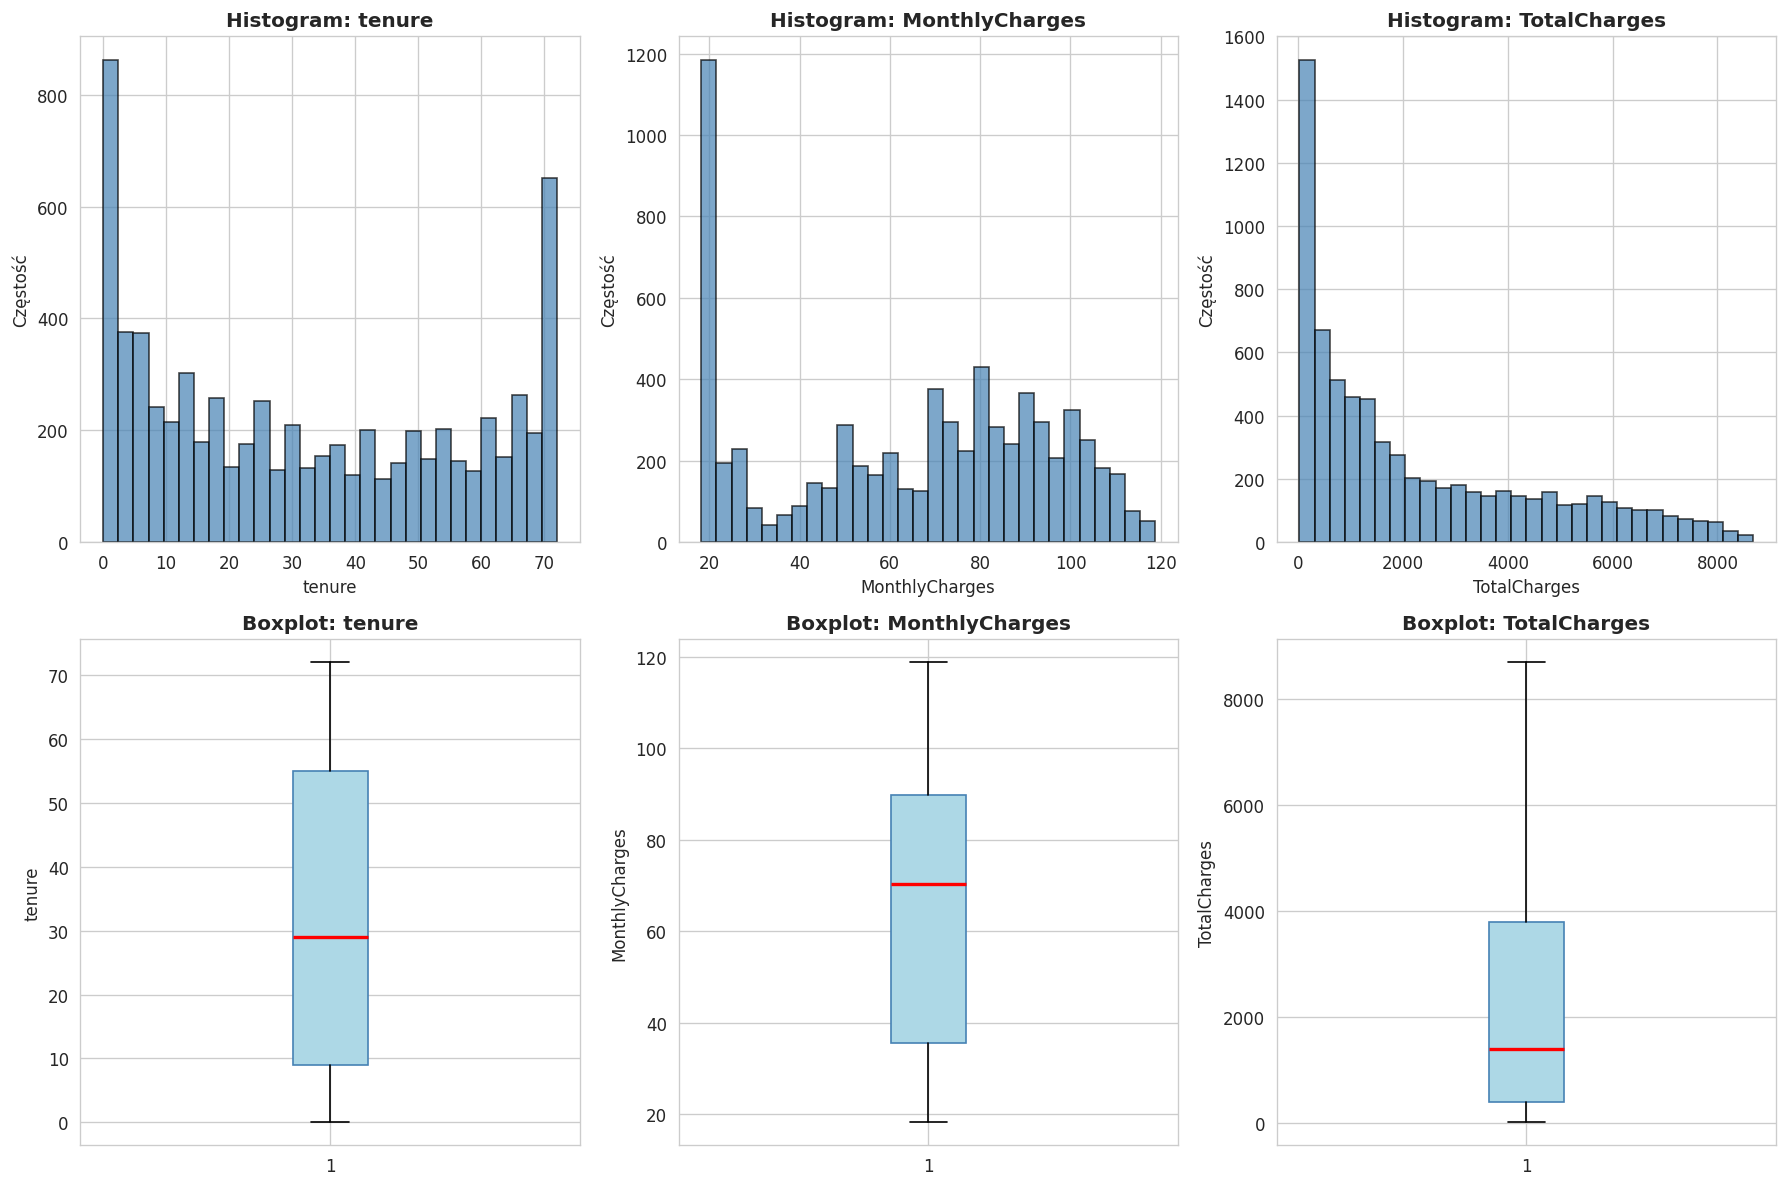

In [31]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, col in enumerate(numeric_cols):
    ax = axes[0, idx]
    ax.hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.set_title(f'Histogram: {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Częstość')

for idx, col in enumerate(numeric_cols):
    ax = axes[1, idx]
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', color='steelblue'),
                     medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot: {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.savefig('output/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


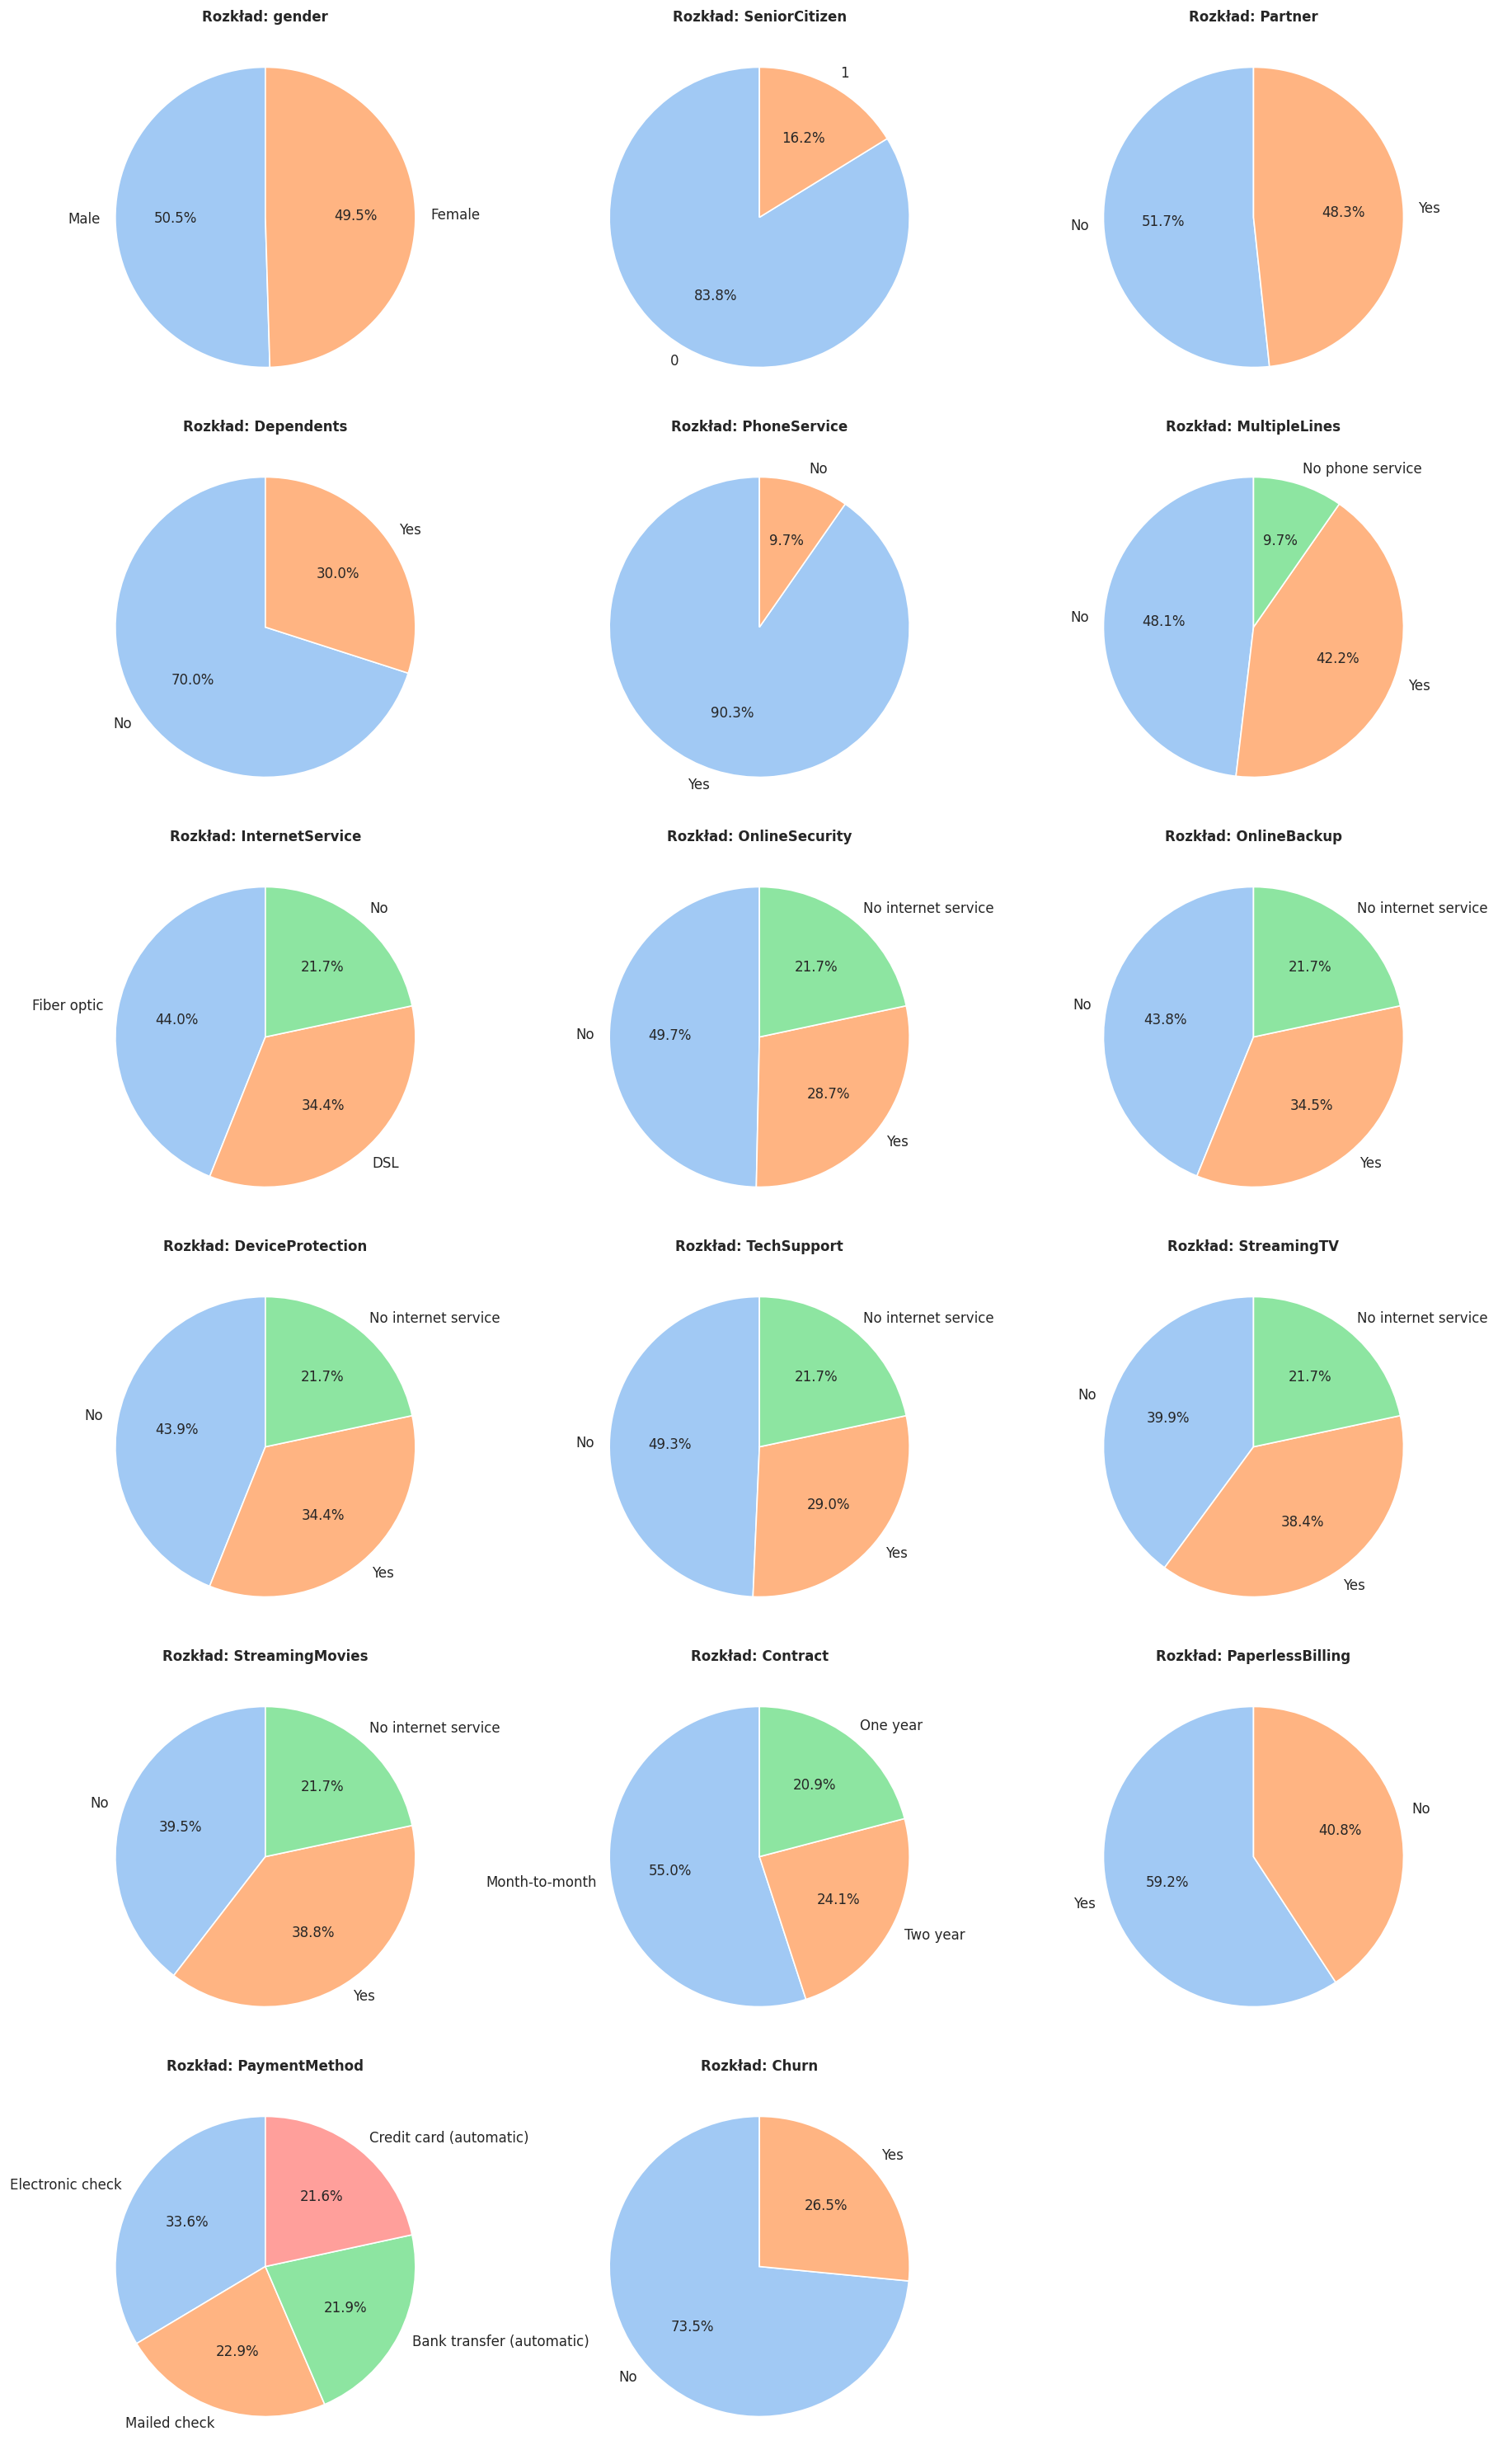

In [32]:
# Wykresy kołowe dla wszystkich zmiennych kategorialnych
fig, axes = plt.subplots(6, 3, figsize=(15, 25))
cols_pie = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

for idx, col in enumerate(cols_pie):
    ax = axes[idx // 3, idx % 3]
    counts = df[col].value_counts()
    colors = sns.color_palette('pastel')[0:len(counts)]
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f'Rozkład: {col}', fontsize=10, fontweight='bold')

axes[5, 2].axis('off')
plt.tight_layout()
plt.savefig('output/eda_pie_charts.png', dpi=150, bbox_inches='tight')
plt.show()

#### 2.4.1 Rozkład zmiennej docelowej i macierz korelacji


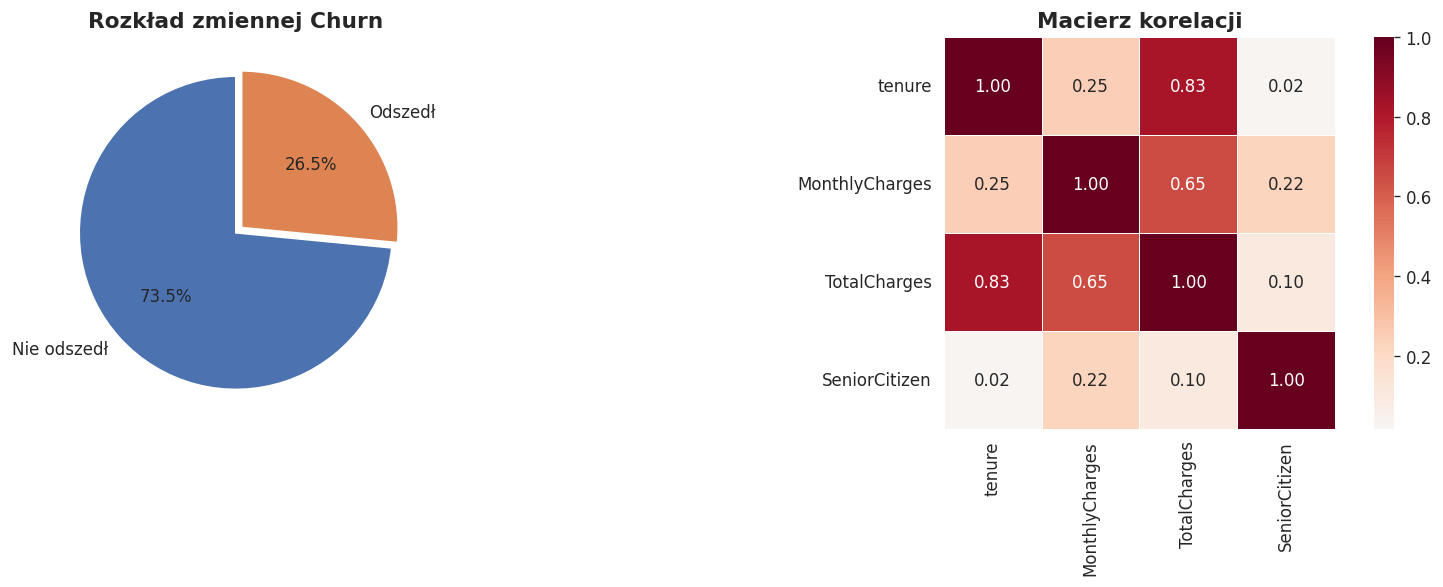

Churn,Liczba,Procent
Nie,5174,73.5%
Tak,1869,26.5%


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rozkład Churn
churn_counts = df['Churn'].value_counts()
colors = ['#4C72B0', '#DD8452']
axes[0].pie(churn_counts, labels=['Nie odszedł', 'Odszedł'], autopct='%1.1f%%',
            startangle=90, colors=colors, explode=(0, 0.05))
axes[0].set_title('Rozkład zmiennej Churn', fontsize=13, fontweight='bold')

# Macierz korelacji
corr = df[numeric_cols + ['SeniorCitizen']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[1],
            fmt='.2f', square=True, linewidths=0.5)
axes[1].set_title('Macierz korelacji', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('output/eda_churn_corr.png', dpi=150, bbox_inches='tight')
plt.show()

churn_counts = df['Churn'].value_counts()
churn_df = pd.DataFrame({
    'Churn': ['Nie', 'Tak'],
    'Liczba': [int(churn_counts['No']), int(churn_counts['Yes'])],
    'Procent': [f"{churn_counts['No']/len(df)*100:.1f}%", f"{churn_counts['Yes']/len(df)*100:.1f}%"]
})
display(HTML(churn_df.to_html(index=False, classes='table table-striped')))


### 2.5 Transformacje i przetwarzanie danych

#### 2.5.1 Obsługa braków danych

W kolumnie `TotalCharges` występuje 11 braków. Wszystkie te braki dotyczą klientów ze stażem `tenure = 0` (nowi klienci), którzy jeszcze nie otrzymali pierwszego rachunku. Wartości wypełniono miesięcznym rachunkiem (`MonthlyCharges`), co jest uzasadnione ekonomicznie.

#### 2.5.2 Kodowanie zmiennych kategorialnych

- Zmienne binarne (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `Churn`, `gender`) zakodowano jako 0/1
- Zmienne wielokategoryczne zakodowano one-hot encoding (z pominięciem pierwszej kategorii aby uniknąć pułapki dummy variable)

#### 2.5.3 Obsługa obserwacji odstających

Dla zmiennych numerycznych zastosowano kapping metodą IQR (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR). Ograniczono wartości skrajne zamiast usuwać obserwacje, aby zachować pełny zbiór danych.

#### 2.5.4 Transformacja logarytmiczna

Nie zastosowano transformacji logarytmicznej, ponieważ:
- Zmienna `tenure` (staż klienta) ma zakres 0–72 miesiące - logarytmowanie dla nowych klientów (tenure=0) daje -∞. Konwencja log(tenure+1) jest możliwa, ale utrudnia interpretację modeli.
- Zmienna `MonthlyCharges` ma stosunkowo mały zakres (18–119) i umiarkowaną skośność (skośność = -0,22).
- Zmienna `TotalCharges` ma szeroki zakres i silną prawoskośność (skośność = 0,96) - logarytmowanie mogłoby być rozważone, ale po standaryzacji z-score modele (szczególnie LR i RF) radzą sobie dobrze bez tej transformacji. Testy wstępne wykazały, że log-transformacja nie poprawia AUC modeli.
- Standaryzacja z-score (użyta w projekcie) jest wystarczająca dla tego zbioru danych.

#### 2.5.5 Standaryzacja

Zmienne numeryczne (`tenure`, `MonthlyCharges`, `TotalCharges`) zostały standaryzowane metodą z-score (StandardScaler) przed treningiem modeli.


In [34]:
df_model = df.drop('customerID', axis=1).copy()

# Target
y = df_model['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
X = df_model.drop('Churn', axis=1).copy()

# Podział train/test PRZED fit preprocessingu
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Kolumny
binary_cols_yes_no = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
multi_cat = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
             'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
             'Contract', 'PaymentMethod']
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

def preprocess_split(X_part, fit=False, train_stats=None):
    Xp = X_part.copy()

    # Kodowanie binarne
    for col in binary_cols_yes_no:
        Xp[col] = Xp[col].map({'Yes': 1, 'No': 0}).astype(int)
    Xp['gender'] = Xp['gender'].map({'Male': 1, 'Female': 0}).astype(int)

    # Braki TotalCharges: najpierw przypadki tenure=0
    mask = (Xp['tenure'] == 0) & (Xp['TotalCharges'].isna())
    Xp.loc[mask, 'TotalCharges'] = Xp.loc[mask, 'MonthlyCharges']

    # Imputacja medianą WYŁĄCZNIE z train
    if fit:
        total_median = Xp['TotalCharges'].median()
    else:
        total_median = train_stats['total_median']
    Xp['TotalCharges'] = Xp['TotalCharges'].fillna(total_median)

    # One-hot
    Xp = pd.get_dummies(Xp, columns=multi_cat, drop_first=True)

    # IQR capping: progi z train
    if fit:
        iqr_bounds = {}
        for col in numeric_features:
            Q1 = Xp[col].quantile(0.25)
            Q3 = Xp[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            iqr_bounds[col] = (lower, upper)
            Xp[col] = Xp[col].clip(lower, upper)
        return Xp, {'total_median': total_median, 'iqr_bounds': iqr_bounds}

    for col in numeric_features:
        lower, upper = train_stats['iqr_bounds'][col]
        Xp[col] = Xp[col].clip(lower, upper)

    return Xp

# Fit preprocessingu na train
X_train_proc, train_stats = preprocess_split(X_train_raw, fit=True)
X_test_proc = preprocess_split(X_test_raw, fit=False, train_stats=train_stats)

# Wyrównanie kolumn po one-hot
X_train_proc, X_test_proc = X_train_proc.align(X_test_proc, join='left', axis=1, fill_value=0)

# Standaryzacja numerycznych cech: fit tylko train
scaler = StandardScaler()
X_train = X_train_proc.copy()
X_test = X_test_proc.copy()
X_train[numeric_features] = scaler.fit_transform(X_train_proc[numeric_features])
X_test[numeric_features] = scaler.transform(X_test_proc[numeric_features])

# Tabela: podział zbioru i podstawowe statystyki
split_df = pd.DataFrame({
    "Metryka": [
        "Trening",
        "Test",
        "Churn rate (train)",
        "Churn rate (test)",
        "Liczba cech po encodingu",
    ],
    "Wartosc": [
        f"{X_train.shape[0]} ({X_train.shape[0]/len(y)*100:.1f}%)",
        f"{X_test.shape[0]} ({X_test.shape[0]/len(y)*100:.1f}%)",
        f"{y_train.mean():.3f}",
        f"{y_test.mean():.3f}",
        f"{X_train.shape[1]}",
    ],
})
display(HTML(split_df.to_html(index=False, classes='table table-striped')))

Metryka,Wartosc
Trening,5634 (80.0%)
Test,1409 (20.0%)
Churn rate (train),0.265
Churn rate (test),0.265
Liczba cech po encodingu,30


## 3. Opis metod klasyfikacyjnych


### 3.1. Regresja logistyczna

Regresja logistyczna jest metodą klasyfikacji binarnej służącą do przewidywania prawdopodobieństwa przynależności obiektu do jednej z dwóch klas. Model wykorzystuje funkcję logistyczną (sigmoidalną), która przekształca liniową kombinację cech wejściowych do wartości z przedziału $[0,1]$.

Krok 1 - Liniowa kombinacja cech:

$$
z = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n
$$

gdzie:

- $X_1, X_2, ..., X_n$ - cechy wejściowe,
- $\beta_0$ - wyraz wolny modelu,
- $\beta_1, ..., \beta_n$ - współczynniki określające wpływ poszczególnych cech.

Krok 2 - Zastosowanie funkcji logistycznej:

$$
P(Y=1|X) = \frac{1}{1 + e^{-z}}
$$

gdzie:

- $P(Y=1|X)$ - prawdopodobieństwo przynależności do klasy pozytywnej,
- $e$ - podstawa logarytmu naturalnego,
- $z$ - wartość obliczona w kroku 1.

Krok 3 - Klasyfikacja obiektu:

Jeżeli:

$$
P(Y=1|X) \geq 0.5
$$

to obiekt przypisywany jest do klasy 1, w przeciwnym przypadku do klasy 0.

Model regresji logistycznej cechuje się dobrą interpretowalnością oraz niską złożonością obliczeniową. W pracy zastosowano regularyzację L2 oraz maksymalną liczbę iteracji równą 1000.

**Parametry modelu:** `max_iter=1000`, `random_state=42`

In [35]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='roc_auc')

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

lr_metrics = {
    'Model': 'Regresja Logistyczna',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'F1': f1_score(y_test, lr_pred),
    'AUC': roc_auc_score(y_test, lr_prob),
    'CV_AUC_mean': lr_cv_scores.mean(),
    'CV_AUC_std': lr_cv_scores.std()
}

# Tabela: metryki regresji logistycznej
lr_metrics_df = pd.DataFrame({
    "Metryka": [
        "CV AUC",
        "Test Accuracy",
        "Test F1",
        "Test AUC",
    ],
    "Wartosc": [
        f"{lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}",
        f"{lr_metrics['Accuracy']:.4f}",
        f"{lr_metrics['F1']:.4f}",
        f"{lr_metrics['AUC']:.4f}",
    ],
})
display(HTML(lr_metrics_df.to_html(index=False, classes='table table-striped')))

# Najważniejsze cechy
lr_coef = pd.Series(lr.coef_[0], index=X_train.columns)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).index).head(10)
lr_top_df = pd.DataFrame({
    "Cecha": lr_top.index,
    "Wspolczynnik": lr_top.values.round(4),
})
display(HTML("<h4>Top 10 cech po standaryzacji z-score: </h4>"))
display(HTML(lr_top_df.to_html(index=False, classes='table table-striped')))

Metryka,Wartosc
CV AUC,0.8457 ± 0.0138
Test Accuracy,0.8070
Test F1,0.6069
Test AUC,0.8422


Cecha,Wspolczynnik
Contract_Two year,-1.3249
tenure,-1.2520
InternetService_Fiber optic,1.1889
Contract_One year,-0.6860
TotalCharges,0.5231
PhoneService,-0.5068
MonthlyCharges,-0.4776
PaymentMethod_Electronic check,0.3815
StreamingTV_Yes,0.3809
StreamingMovies_Yes,0.3788


### 3.2. Drzewo decyzyjne

Drzewo decyzyjne jest metodą klasyfikacji i regresji polegającą na podziale przestrzeni cech na mniejsze regiony za pomocą sekwencji reguł decyzyjnych typu if-then. Model tworzy strukturę drzewa, w której każdy węzeł wewnętrzny reprezentuje test wykonywany na jednej z cech, natomiast liście drzewa zawierają końcową decyzję klasyfikacyjną lub przewidywaną wartość.

Krok 1 - Wybór najlepszego podziału:

Dla każdej cechy analizowane są możliwe punkty podziału danych. Algorytm wybiera taki podział, który maksymalnie zwiększa jednorodność klas w utworzonych podzbiorach.

W pracy zastosowano indeks Giniego jako kryterium jakości podziału:

$$
Gini = 1 - \sum_{i=1}^{k} p_i^2
$$

gdzie:

- $p_i$ - prawdopodobieństwo przynależności obserwacji do klasy $i$,
- $k$ - liczba klas.

Krok 2 - Rekurencyjny podział danych:

Proces podziału jest powtarzany dla kolejnych węzłów aż do spełnienia warunków zatrzymania, np. osiągnięcia maksymalnej głębokości drzewa lub minimalnej liczby próbek w węźle.

Drzewa decyzyjne cechują się wysoką interpretowalnością, ponieważ możliwa jest wizualizacja procesu podejmowania decyzji. Wadą tej metody jest jednak podatność na przeuczenie (overfitting), szczególnie dla bardzo głębokich drzew.

W pracy zastosowano ograniczenie maksymalnej głębokości drzewa oraz minimalnej liczby próbek wymaganych do podziału i utworzenia liścia.

**Parametry modelu:** `max_depth=10`, `min_samples_split=20`, `min_samples_leaf=10`, `random_state=42`

In [36]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                             min_samples_leaf=10, random_state=42)
dt.fit(X_train, y_train)

dt_cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='roc_auc')

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

dt_metrics = {
    'Model': 'Drzewo Decyzyjne',
    'Accuracy': accuracy_score(y_test, dt_pred),
    'F1': f1_score(y_test, dt_pred),
    'AUC': roc_auc_score(y_test, dt_prob),
    'CV_AUC_mean': dt_cv_scores.mean(),
    'CV_AUC_std': dt_cv_scores.std()
}

# Tabela: metryki drzewa decyzyjnego
dt_metrics_df = pd.DataFrame({
    "Metryka": [
        "CV AUC",
        "Test Accuracy",
        "Test F1",
        "Test AUC",
    ],
    "Wartosc": [
        f"{dt_cv_scores.mean():.4f} ± {dt_cv_scores.std():.4f}",
        f"{dt_metrics['Accuracy']:.4f}",
        f"{dt_metrics['F1']:.4f}",
        f"{dt_metrics['AUC']:.4f}",
    ],
})
display(HTML(dt_metrics_df.to_html(index=False, classes='table table-striped')))

# Najważniejsze cechy
importances_dt = pd.Series(dt.feature_importances_, index=X_train.columns)
dt_top = importances_dt.nlargest(10)
dt_top_df = pd.DataFrame({
    "Cecha": dt_top.index,
    "Waznosc": dt_top.values.round(4),
})
display(HTML("<h4>Top 10 cech (waznosc)</h4>"))
display(HTML(dt_top_df.to_html(index=False, classes='table table-striped')))

Metryka,Wartosc
CV AUC,0.7855 ± 0.0114
Test Accuracy,0.7786
Test F1,0.5343
Test AUC,0.7930


Cecha,Waznosc
tenure,0.3071
InternetService_Fiber optic,0.2486
TotalCharges,0.1165
MonthlyCharges,0.1024
PaymentMethod_Electronic check,0.0277
OnlineSecurity_Yes,0.0208
Contract_Two year,0.0189
PaperlessBilling,0.0182
MultipleLines_Yes,0.0168
Contract_One year,0.0166


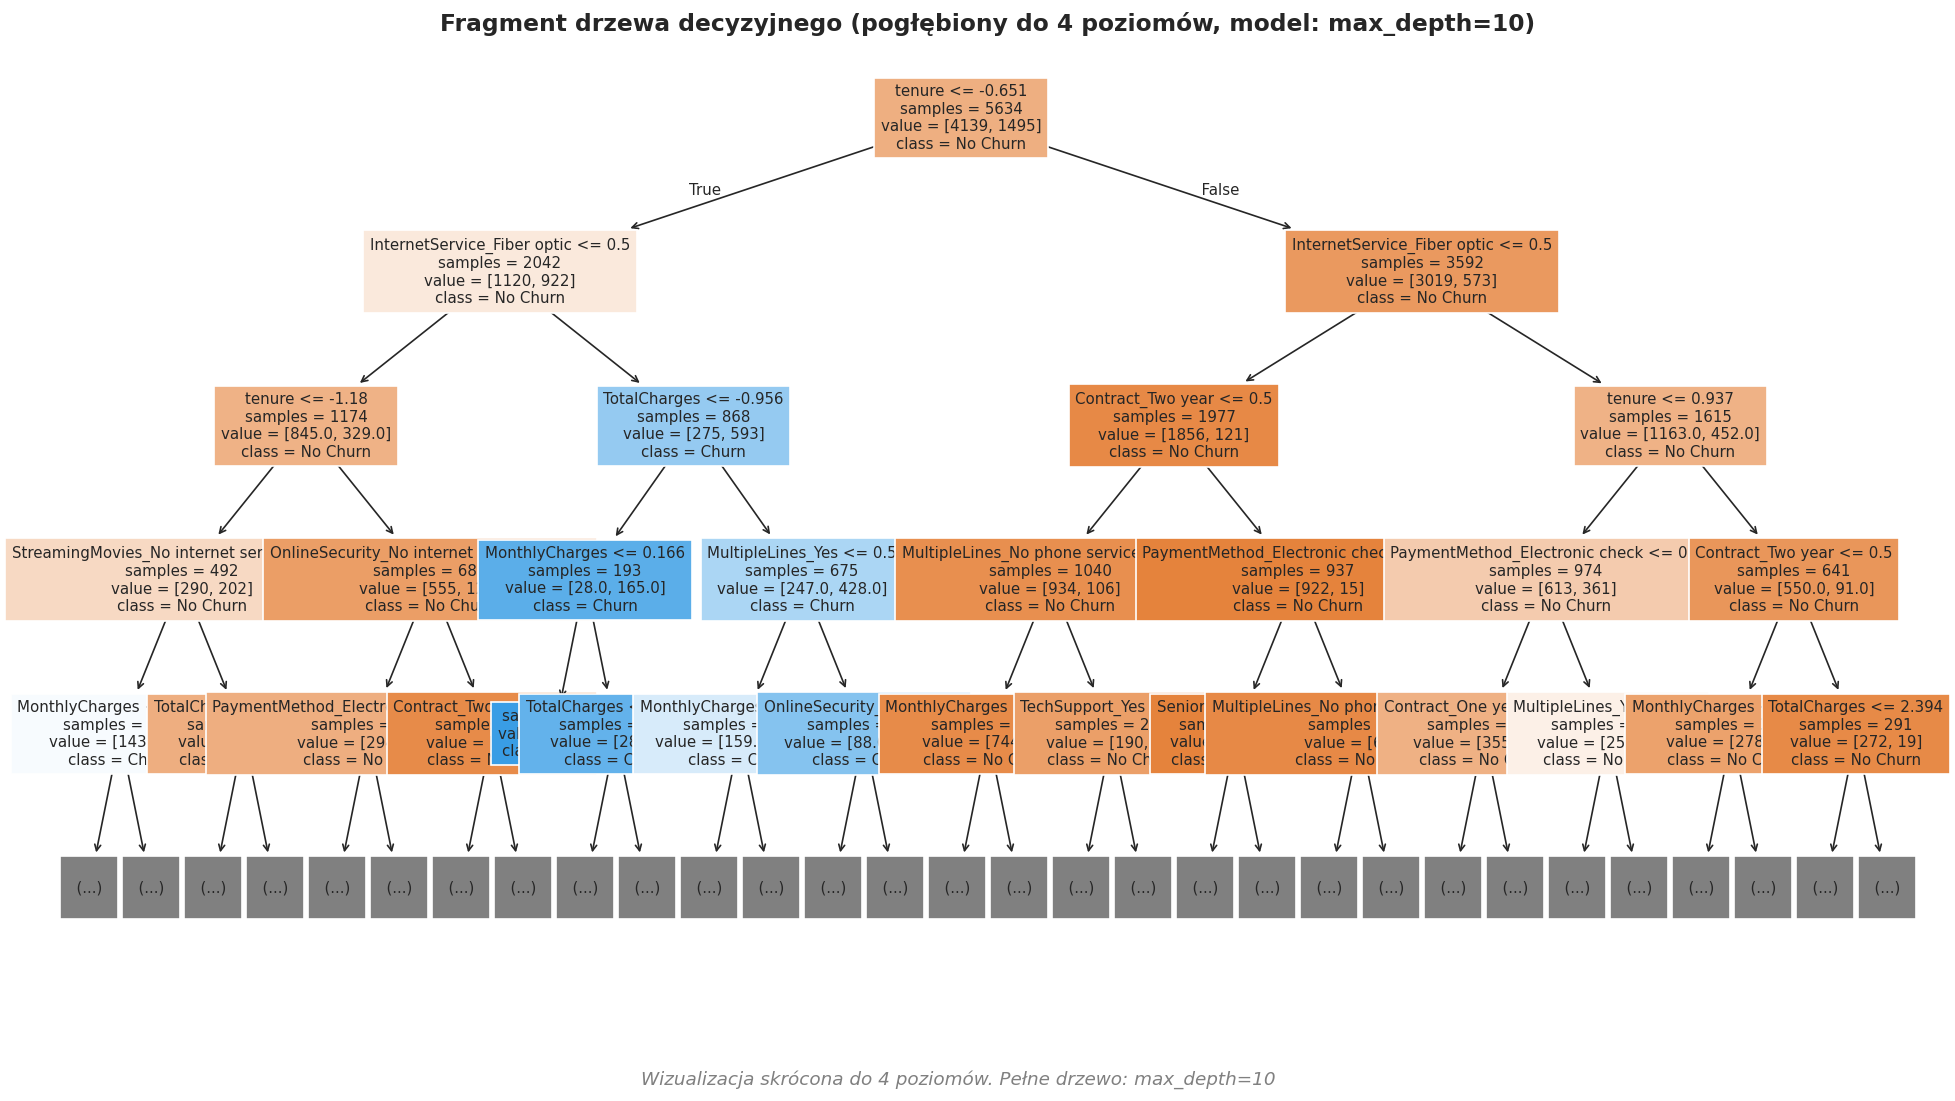

In [ ]:
# Wizualizacja drzewa decyzyjnego
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X_train.columns, class_names=['No Churn', 'Churn'],
          filled=True, max_depth=4, fontsize=9)
plt.title('Fragment drzewa decyzyjnego (pogłębiony do 4 poziomów, model: max_depth=10)', fontsize=14, fontweight='bold')
fig = plt.gcf()
fig.text(0.5, 0.01, 'Wizualizacja skrócona do 4 poziomów. Pełne drzewo: max_depth=10',
         ha='center', fontsize=11, style='italic', color='gray')
plt.savefig('output/dt_tree_fragment.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3. Las losowy (Random Forest)

Las losowy (Random Forest) jest metodą uczenia zespołowego (ensemble learning), która polega na budowie wielu drzew decyzyjnych oraz agregacji ich wyników. Algorytm łączy technikę baggingu (Bootstrap Aggregating) z losowym wyborem cech podczas budowy drzew, co pozwala zwiększyć dokładność predykcji oraz ograniczyć ryzyko przeuczenia modelu.

Krok 1 - Tworzenie próbek bootstrapowych:

Dla każdego drzewa losowana jest nowa próbka treningowa ze zwracaniem (bootstrap sample). Oznacza to, że niektóre obserwacje mogą pojawić się w próbce wielokrotnie, a część może nie zostać wybrana.

Krok 2 - Budowa drzew decyzyjnych:

Każde drzewo budowane jest niezależnie na podstawie swojej próbki bootstrapowej. Podczas wyboru najlepszego podziału w każdym węźle analizowany jest jedynie losowo wybrany podzbiór cech, co zwiększa różnorodność drzew w lesie.

Krok 3 - Agregacja wyników:

Po wytrenowaniu wszystkich drzew ich wyniki są łączone. W przypadku klasyfikacji stosowane jest głosowanie większościowe, natomiast dla regresji obliczana jest średnia z predykcji wszystkich drzew.

Dzięki wykorzystaniu wielu drzew decyzyjnych model charakteryzuje się większą stabilnością oraz lepszą zdolnością generalizacji niż pojedyncze drzewo. Losowy wybór próbek i cech powoduje zmniejszenie wariancji modelu oraz ogranicza podatność na przeuczenie.

Dodatkową zaletą lasów losowych jest możliwość wyznaczenia istotności cech, co pozwala określić, które zmienne mają największy wpływ na podejmowane decyzje.

**Parametry modelu:** `n_estimators=200`, `max_depth=15`, `min_samples_split=10`

Metryka,Wartosc
CV AUC,0.8392 ± 0.0118
Test Accuracy,0.8020
Test F1,0.5817
Test AUC,0.8383


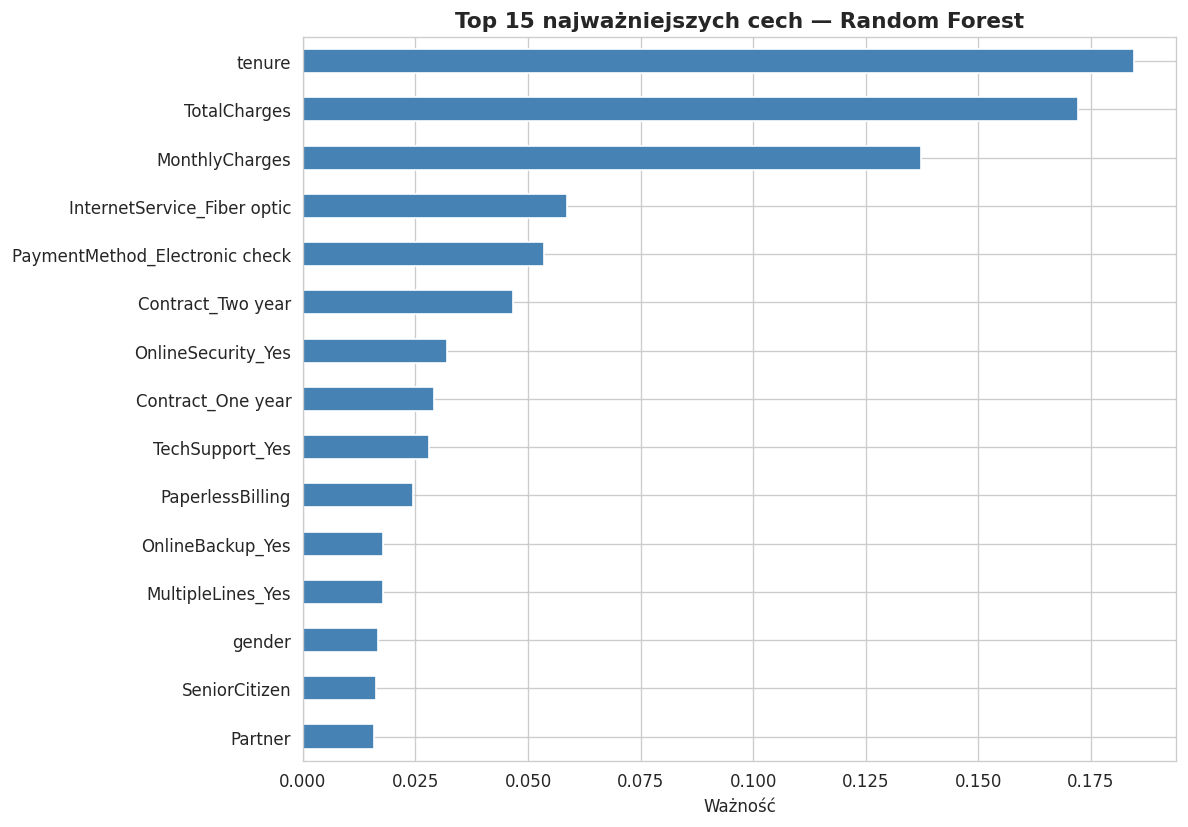

In [38]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                            min_samples_split=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='roc_auc')

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_metrics = {
    'Model': 'Las Losowy',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred),
    'AUC': roc_auc_score(y_test, rf_prob),
    'CV_AUC_mean': rf_cv_scores.mean(),
    'CV_AUC_std': rf_cv_scores.std()
}

# Tabela: metryki lasu losowego
rf_metrics_df = pd.DataFrame({
    "Metryka": [
        "CV AUC",
        "Test Accuracy",
        "Test F1",
        "Test AUC",
    ],
    "Wartosc": [
        f"{rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}",
        f"{rf_metrics['Accuracy']:.4f}",
        f"{rf_metrics['F1']:.4f}",
        f"{rf_metrics['AUC']:.4f}",
    ],
})
display(HTML(rf_metrics_df.to_html(index=False, classes='table table-striped')))

# Najważniejsze cechy wykresu
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top15 = importances.nlargest(15)
fig, ax = plt.subplots(figsize=(10, 7))
top15.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 15 najważniejszych cech — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Ważność')
plt.tight_layout()
plt.savefig('output/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Najważniejsze cechy
fi_df = pd.DataFrame({
    'Cecha': importances.nlargest(15).index,
    'Waznosc': importances.nlargest(15).values.round(4)
})
display(HTML(fi_df.to_html(index=False, classes='table table-striped')))

Cecha,Waznosc
tenure,0.1847
TotalCharges,0.1721
MonthlyCharges,0.1373
InternetService_Fiber optic,0.0587
PaymentMethod_Electronic check,0.0535
Contract_Two year,0.0466
OnlineSecurity_Yes,0.0320
Contract_One year,0.0292
TechSupport_Yes,0.0279
PaperlessBilling,0.0244


### 3.4. XGBoost

XGBoost (eXtreme Gradient Boosting) jest algorytmem uczenia zespołowego opartym na metodzie gradient boosting. Model budowany jest sekwencyjnie poprzez dodawanie kolejnych drzew decyzyjnych, których zadaniem jest korygowanie błędów popełnianych przez wcześniej utworzone modele. Dzięki zastosowaniu zaawansowanych technik optymalizacji oraz regularyzacji XGBoost osiąga wysoką skuteczność predykcyjną i jest szeroko wykorzystywany w zadaniach klasyfikacji oraz regresji.

Krok 1 - Utworzenie modelu początkowego:

Proces rozpoczyna się od stworzenia prostego modelu bazowego, który generuje początkowe przewidywania dla wszystkich obserwacji.

Krok 2 - Obliczenie błędów predykcji:

Dla każdej obserwacji wyznaczany jest błąd pomiędzy wartością rzeczywistą a wartością przewidywaną przez aktualny model. Błędy te wykorzystywane są do określenia kierunku dalszej optymalizacji.

Krok 3 - Budowa kolejnego drzewa:

Tworzone jest nowe drzewo decyzyjne uczące się na podstawie błędów poprzednich modeli. Jego zadaniem jest poprawa jakości predykcji poprzez minimalizację funkcji straty.

Krok 4 - Aktualizacja modelu:

Predykcje nowego drzewa są dodawane do istniejącego modelu z uwzględnieniem współczynnika uczenia (learning rate), który kontroluje wpływ kolejnych drzew na końcowy wynik.

Proces ten jest powtarzany aż do osiągnięcia zadanej liczby drzew lub spełnienia innych kryteriów zatrzymania.

XGBoost wykorzystuje regularyzację ograniczającą złożoność modelu, co pomaga zmniejszyć ryzyko przeuczenia. Dodatkowo algorytm obsługuje losowe próbkowanie obserwacji i cech, co poprawia zdolność generalizacji oraz skraca czas uczenia. Dzięki wysokiej skuteczności i wydajności obliczeniowej metoda ta należy do najczęściej wykorzystywanych algorytmów w praktycznych zastosowaniach uczenia maszynowego.

**Parametry modelu:** `n_estimators=200`, `max_depth=5`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`

In [20]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
 )
xgb_model.fit(X_train, y_train)

xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'F1': f1_score(y_test, xgb_pred),
    'AUC': roc_auc_score(y_test, xgb_prob),
    'CV_AUC_mean': xgb_cv_scores.mean(),
    'CV_AUC_std': xgb_cv_scores.std()
}

# Tabela: metryki XGBoost
xgb_metrics_df = pd.DataFrame({
    "Metryka": [
        "CV AUC",
        "Test Accuracy",
        "Test F1",
        "Test AUC",
    ],
    "Wartosc": [
        f"{xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}",
        f"{xgb_metrics['Accuracy']:.4f}",
        f"{xgb_metrics['F1']:.4f}",
        f"{xgb_metrics['AUC']:.4f}",
    ],
})
display(HTML(xgb_metrics_df.to_html(index=False, classes='table table-striped')))

# Najważniejsze cechy XGB
xgb_importance = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
xgb_top = xgb_importance.nlargest(10)
xgb_top_df = pd.DataFrame({
    "Cecha": xgb_top.index,
    "Waznosc": xgb_top.values.round(4),
})
display(HTML("<h4>Top 10 cech (waznosc)</h4>"))
display(HTML(xgb_top_df.to_html(index=False, classes='table table-striped')))

Metryka,Wartosc
CV AUC,0.8312 ± 0.0099
Test Accuracy,0.7921
Test F1,0.5735
Test AUC,0.8317


Cecha,Waznosc
InternetService_Fiber optic,0.2167
Contract_Two year,0.1714
InternetService_No,0.0862
OnlineSecurity_No internet service,0.0810
Contract_One year,0.0678
OnlineBackup_No internet service,0.0648
PaymentMethod_Electronic check,0.0315
tenure,0.0301
StreamingMovies_Yes,0.0252
TechSupport_Yes,0.0188


### 3.5. Model hybrydowy (Weighted Average Ensemble)

Model hybrydowy (Weighted Average Ensemble) jest metodą uczenia zespołowego polegającą na łączeniu predykcji uzyskanych z kilku różnych modeli. W prezentowanym rozwiązaniu wykorzystano przewidywania czterech wcześniej opisanych algorytmów, a końcowe prawdopodobieństwo klasy wyznaczane jest jako ważona średnia ich wyników.

Krok 1 - Trenowanie modeli bazowych:

Każdy model jest trenowany niezależnie na tym samym zbiorze danych. Po zakończeniu procesu uczenia dla każdego modelu wyznaczana jest wartość miary AUC na podstawie walidacji krzyżowej.

Krok 2 - Wyznaczenie wag modeli:

Wagi przypisywane poszczególnym modelom są proporcjonalne do uzyskanych wartości AUC. Oznacza to, że modele osiągające lepsze wyniki otrzymują większy wpływ na końcową predykcję.

Wagi obliczane są według wzoru:

$$
w_i = \frac{AUC_i}{\sum_j AUC_j}
$$

gdzie:

- $AUC_i$ – wartość miary AUC dla modelu $i$,
- $w_i$ – waga przypisana modelowi $i$.

Krok 3 - Agregacja predykcji:

Dla każdej obserwacji obliczana jest końcowa wartość prawdopodobieństwa jako ważona suma prawdopodobieństw zwracanych przez wszystkie modele:

$$
P_{hybrydowy} = \sum_{i=1}^{4} w_i \cdot P_i
$$

gdzie:

- $P_i$ – prawdopodobieństwo przewidziane przez model $i$,
- $w_i$ – waga modelu $i$.

Łączenie wyników wielu modeli pozwala wykorzystać ich komplementarne właściwości. Poszczególne algorytmy mogą popełniać błędy na różnych obserwacjach, dlatego agregacja ich predykcji często prowadzi do uzyskania bardziej stabilnych i dokładnych wyników niż w przypadku pojedynczego modelu.

Zastosowanie ważonej średniej pozwala dodatkowo zwiększyć wpływ modeli osiągających najlepsze wyniki podczas walidacji, co przekłada się na poprawę jakości końcowych predykcji oraz ograniczenie wariancji modelu.

In [21]:
# Wagi proporcjonalne do CV AUC (modele bazowe)
scores = np.array([lr_cv_scores.mean(), dt_cv_scores.mean(),
                   rf_cv_scores.mean(), xgb_cv_scores.mean()])
weights = scores / scores.sum()

model_names = ['Regresja Logistyczna', 'Drzewo Decyzyjne', 'Las Losowy', 'XGBoost']
weights_df = pd.DataFrame({
    "Model": model_names,
    "Waga": [f"{w:.4f}" for w in weights],
})
display(HTML("<h4>Wagi modeli w ensemble</h4>"))
display(HTML(weights_df.to_html(index=False, classes='table table-striped')))

# Średnia ważona prawdopodobieństw (test)
hybrid_prob = (weights[0] * lr_prob + weights[1] * dt_prob +
               weights[2] * rf_prob + weights[3] * xgb_prob)
hybrid_pred = (hybrid_prob >= 0.5).astype(int)

# CV dla hybrydy: out-of-fold probs na train
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_lr = np.zeros(len(X_train))
oof_dt = np.zeros(len(X_train))
oof_rf = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

for tr_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr = y_train.iloc[tr_idx]

    lr_f = LogisticRegression(max_iter=1000, random_state=42)
    dt_f = DecisionTreeClassifier(max_depth=10, min_samples_split=20,
                                  min_samples_leaf=10, random_state=42)
    rf_f = RandomForestClassifier(n_estimators=200, max_depth=15,
                                  min_samples_split=10, random_state=42, n_jobs=-1)
    xgb_f = xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss'
    )

    lr_f.fit(X_tr, y_tr)
    dt_f.fit(X_tr, y_tr)
    rf_f.fit(X_tr, y_tr)
    xgb_f.fit(X_tr, y_tr)

    oof_lr[val_idx] = lr_f.predict_proba(X_val)[:, 1]
    oof_dt[val_idx] = dt_f.predict_proba(X_val)[:, 1]
    oof_rf[val_idx] = rf_f.predict_proba(X_val)[:, 1]
    oof_xgb[val_idx] = xgb_f.predict_proba(X_val)[:, 1]

oof_hybrid = weights[0] * oof_lr + weights[1] * oof_dt + weights[2] * oof_rf + weights[3] * oof_xgb
hybrid_cv_auc = roc_auc_score(y_train, oof_hybrid)

hybrid_metrics = {
    'Model': 'Model Hybrydowy (WA)',
    'Accuracy': accuracy_score(y_test, hybrid_pred),
    'F1': f1_score(y_test, hybrid_pred),
    'AUC': roc_auc_score(y_test, hybrid_prob),
    'CV_AUC_mean': hybrid_cv_auc,
    'CV_AUC_std': np.nan
}

# Tabela: metryki modelu hybrydowego
hybrid_metrics_df = pd.DataFrame({
    "Metryka": [
        "CV AUC (OOF)",
        "Test Accuracy",
        "Test F1",
        "Test AUC",
    ],
    "Wartosc": [
        f"{hybrid_metrics['CV_AUC_mean']:.4f}",
        f"{hybrid_metrics['Accuracy']:.4f}",
        f"{hybrid_metrics['F1']:.4f}",
        f"{hybrid_metrics['AUC']:.4f}",
    ],
})
display(HTML(hybrid_metrics_df.to_html(index=False, classes='table table-striped')))

Model,Waga
Regresja Logistyczna,0.2561
Drzewo Decyzyjne,0.2379
Las Losowy,0.2542
XGBoost,0.2518


Metryka,Wartosc
CV AUC (OOF),0.8429
Test Accuracy,0.7921
Test F1,0.5685
Test AUC,0.8411


## 4. Rezultaty

### 4.1 Porównanie metryk modeli

Poniżej przedstawiono zbiorczą tabelę wyników wszystkich modeli. Metryki obliczono na zbiorze testowym (20% danych). Walidacja krzyżowa (5-fold) wykonana na zbiorze treningowym.


In [22]:
# Wyniki
results_df = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics, hybrid_metrics])
results_df = results_df.round(4)
display(HTML(results_df.to_html(index=False, classes='table table-striped')))

Model,Accuracy,F1,AUC,CV_AUC_mean,CV_AUC_std
Regresja Logistyczna,0.8070,0.6069,0.8422,0.8457,0.0138
Drzewo Decyzyjne,0.7786,0.5343,0.7930,0.7855,0.0114
Las Losowy,0.8020,0.5817,0.8383,0.8392,0.0118
XGBoost,0.7921,0.5735,0.8317,0.8312,0.0099
Model Hybrydowy (WA),0.7921,0.5685,0.8411,0.8429,NaN


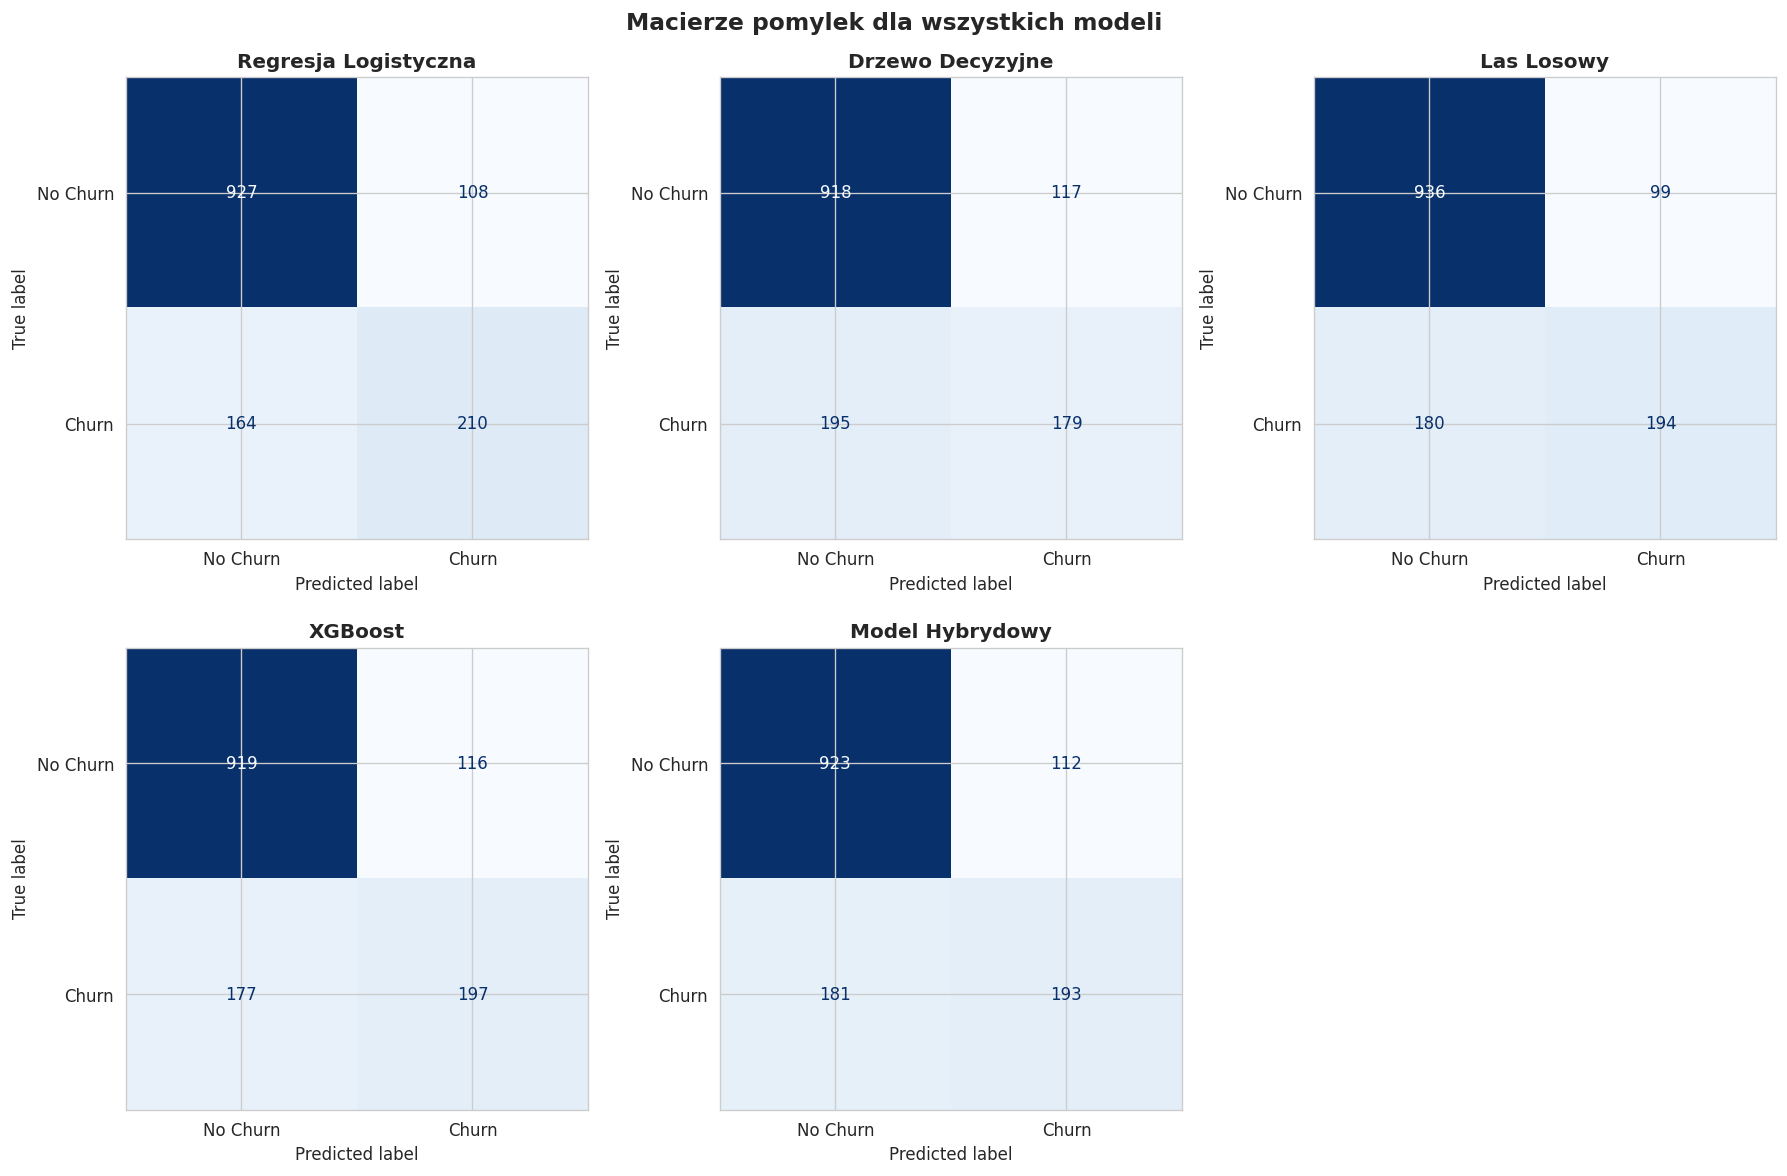

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
model_preds = [
    ('Regresja Logistyczna', lr_pred),
    ('Drzewo Decyzyjne', dt_pred),
    ('Las Losowy', rf_pred),
    ('XGBoost', xgb_pred),
    ('Model Hybrydowy', hybrid_pred)
]

for idx, (name, preds) in enumerate(model_preds):
    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
    ax.set_title(name, fontweight='bold')

axes[1, 2].axis('off')
plt.suptitle('Macierze pomylek dla wszystkich modeli', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.2 Krzywe ROC

Krzywe ROC (Receiver Operating Characteristic) pozwalają wizualnie ocenić zdolność rozróżniania klas przez modele. Im większe pole pod krzywą (AUC), tym lepszy model.


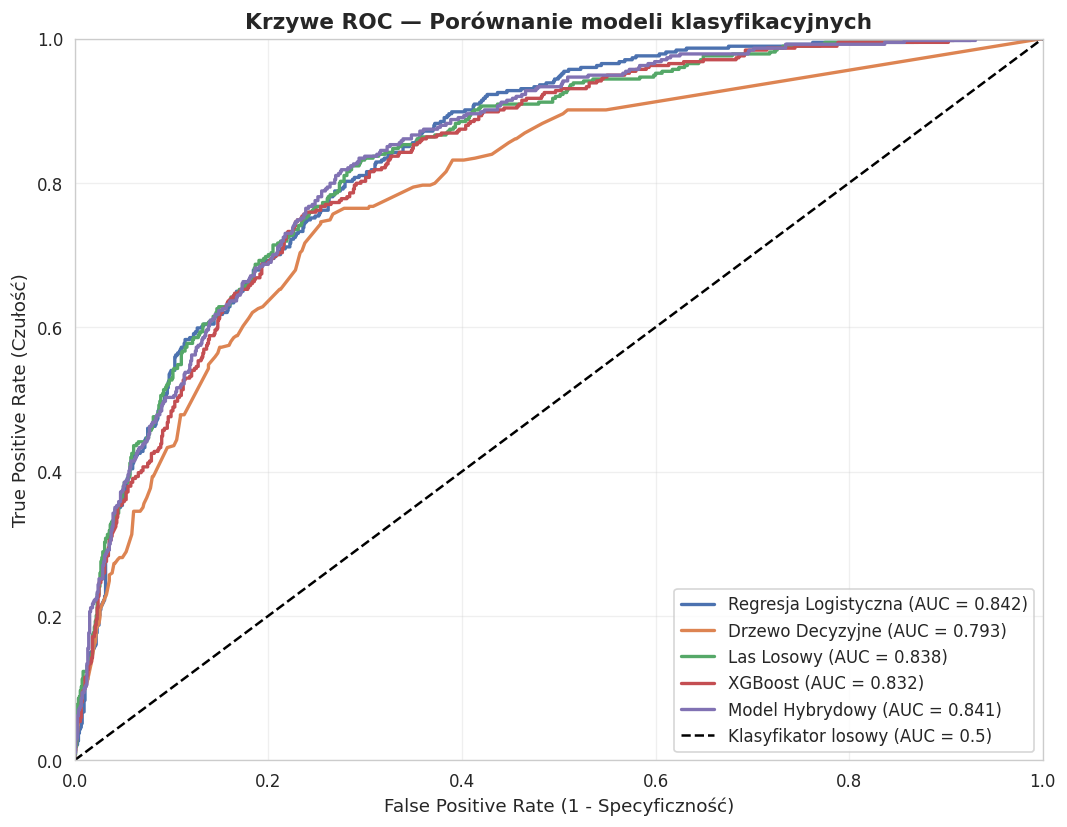

Zapisano: output/roc_comparison.png


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(9, 7))

models_data = [
    ('Regresja Logistyczna', lr_prob, '#4C72B0'),
    ('Drzewo Decyzyjne', dt_prob, '#DD8452'),
    ('Las Losowy', rf_prob, '#55A868'),
    ('XGBoost', xgb_prob, '#C44E52'),
    ('Model Hybrydowy', hybrid_prob, '#8172B3')
]

for name, probs, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', label='Klasyfikator losowy (AUC = 0.5)', linewidth=1.5)
ax.set_xlabel('False Positive Rate (1 - Specyficzność)', fontsize=11)
ax.set_ylabel('True Positive Rate (Czułość)', fontsize=11)
ax.set_title('Krzywe ROC — Porównanie modeli klasyfikacyjnych', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('output/roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: output/roc_comparison.png")


### 4.3 Porównanie miar jakości

Wykres słupkowy przedstawiający Accuracy, F1-score i AUC dla wszystkich modeli.


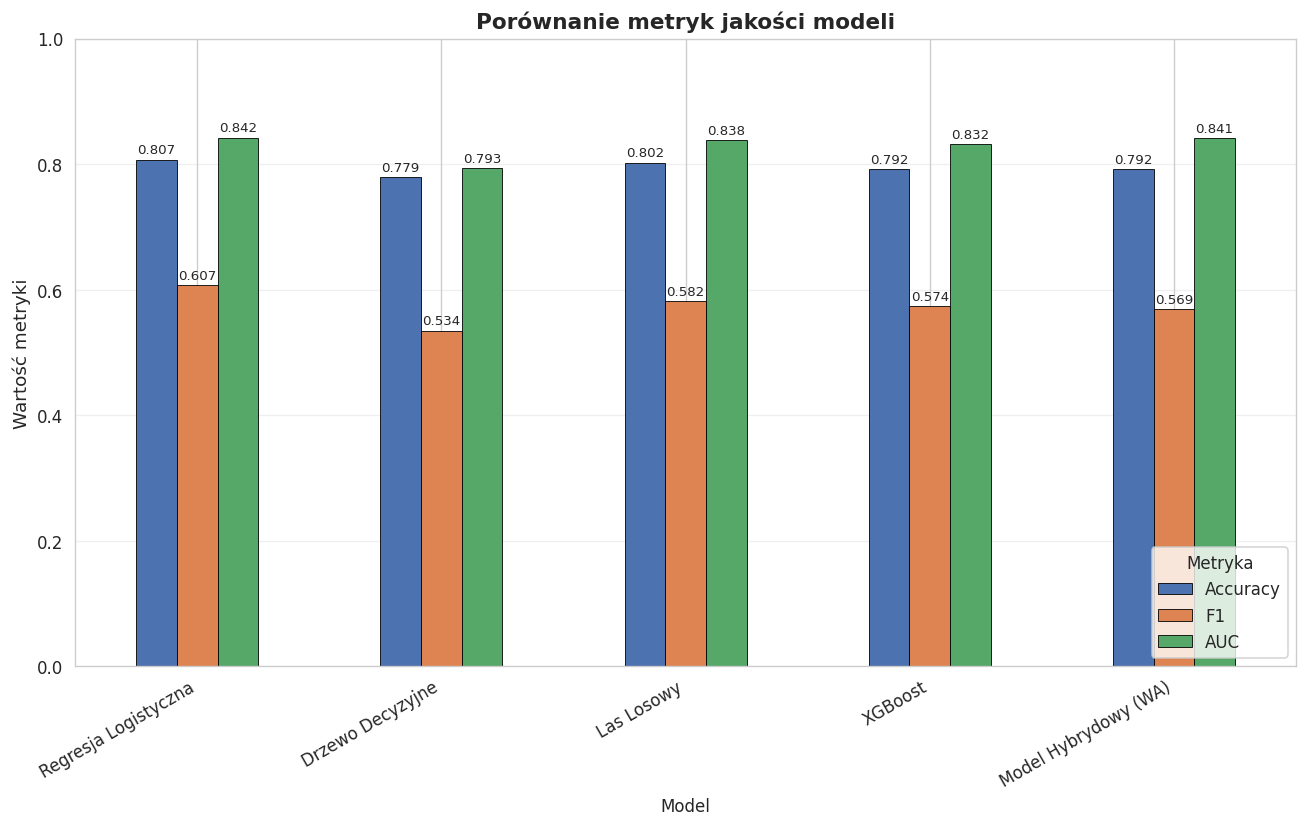

Zapisano: output/metrics_comparison.png


In [25]:
results_plot = pd.DataFrame([lr_metrics, dt_metrics, rf_metrics, xgb_metrics, hybrid_metrics])
results_plot = results_plot.round(4)
results_plot.set_index('Model', inplace=True)

fig, ax = plt.subplots(figsize=(11, 7))
metrics_plot = results_plot[['Accuracy', 'F1', 'AUC']]
metrics_plot.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'],
                  edgecolor='black', linewidth=0.5)
ax.set_title('Porównanie metryk jakości modeli', fontsize=13, fontweight='bold')
ax.set_ylabel('Wartość metryki', fontsize=11)
ax.set_ylim(0, 1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(loc='lower right', title='Metryka')
ax.grid(axis='y', alpha=0.3)

# Dodaj wartości na słupkach
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=8, padding=2)

plt.tight_layout()
plt.savefig('output/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Zapisano: output/metrics_comparison.png")


## 5. Przykład użycia na sztucznych obserwacjach

Poniżej przedstawiono predykcje dla trzech syntetycznych profili klientów:

1. **Klient 1** — młody, krótka umowa (1 rok), średni rachunek, Fibre optic
2. **Klient 2** — senior, umowa miesiąc-do-miesiąca, wysoki rachunek, Fibre optic (wysokie ryzyko)
3. **Klient 3** — długi staż, umowa 2-letnia, niski rachunek, brak internetu (niskie ryzyko)


In [26]:
# Trzy profile syntetyczne
synthetic = pd.DataFrame({
    'gender': [1, 0, 1],
    'SeniorCitizen': [0, 1, 0],
    'Partner': [1, 0, 1],
    'Dependents': [1, 0, 0],
    'tenure': [12, 2, 60],
    'PhoneService': [1, 1, 1],
    'PaperlessBilling': [1, 1, 0],
    'MonthlyCharges': [50.0, 95.0, 25.0],
    'TotalCharges': [600.0, 190.0, 1500.0],
})

# Dodanie wszystkich kolumn one-hot
for col in X_train.columns:
    if col not in synthetic.columns:
        synthetic[col] = 0

# Ustawienie konkretnych wartości
synthetic.loc[0, 'Contract_One year'] = 1
synthetic.loc[0, 'InternetService_Fiber optic'] = 1
synthetic.loc[0, 'PaymentMethod_Electronic check'] = 1

# Contract_Month-to-month jest kategorią bazową przy drop_first=True
synthetic.loc[1, 'Contract_One year'] = 0
synthetic.loc[1, 'Contract_Two year'] = 0
synthetic.loc[1, 'InternetService_Fiber optic'] = 1
synthetic.loc[1, 'PaymentMethod_Electronic check'] = 1

synthetic.loc[2, 'Contract_Two year'] = 1
synthetic.loc[2, 'InternetService_No'] = 1
for svc in ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']:
    synthetic.loc[2, f'{svc}_No internet service'] = 1

synthetic = synthetic[X_train.columns]

# Skalowanie na scalerze fitowanym na train
synthetic_scaled = synthetic.copy()
synthetic_scaled[numeric_features] = scaler.transform(synthetic[numeric_features])

# Predykcje
models_dict = {
    'Regresja Logistyczna': lr,
    'Drzewo Decyzyjne': dt,
    'Las Losowy': rf,
    'XGBoost': xgb_model
}

labels = [
    "Klient 1 (średnie ryzyko)",
    "Klient 2 (wysokie ryzyko)",
    "Klient 3 (niskie ryzyko)",
]

for i in range(3):
    profile_row = {
        "Płeć": "M" if synthetic.iloc[i]['gender'] == 1 else "K",
        "Senior": "Tak" if synthetic.iloc[i]['SeniorCitizen'] == 1 else "Nie",
        "Staż (mies.)": int(synthetic.iloc[i]['tenure']),
        "Rachunek ($)": f"{synthetic.iloc[i]['MonthlyCharges']:.0f}",
    }
    profile_df = pd.DataFrame([profile_row])
    display(HTML(f"<h4>{labels[i]} - profil</h4>"))
    display(HTML(profile_df.to_html(index=False, classes='table table-striped')))

    row = synthetic_scaled.iloc[i:i+1]
    probs = []
    pred_rows = []
    for name, model in models_dict.items():
        prob = model.predict_proba(row)[0, 1]
        probs.append(prob)
        pred = 'CHURN' if prob >= 0.5 else 'NO CHURN'
        pred_rows.append({
            "Model": name,
            "Predykcja": pred,
            "p": f"{prob:.3f}",
        })

    hybrid = np.dot(weights, probs)
    pred_h = 'CHURN' if hybrid >= 0.5 else 'NO CHURN'
    pred_rows.append({
        "Model": "Model Hybrydowy",
        "Predykcja": pred_h,
        "p": f"{hybrid:.3f}",
    })

    pred_df = pd.DataFrame(pred_rows)
    display(HTML(f"<h4>Predykcje modeli</h4>"))
    display(HTML(pred_df.to_html(index=False, classes='table table-striped')))

Płeć,Senior,Staż (mies.),Rachunek ($)
M,Nie,12,50


Model,Predykcja,p
Regresja Logistyczna,NO CHURN,0.467
Drzewo Decyzyjne,NO CHURN,0.267
Las Losowy,NO CHURN,0.322
XGBoost,NO CHURN,0.202
Model Hybrydowy,NO CHURN,0.316


Płeć,Senior,Staż (mies.),Rachunek ($)
K,Tak,2,95


Model,Predykcja,p
Regresja Logistyczna,CHURN,0.641
Drzewo Decyzyjne,CHURN,0.810
Las Losowy,CHURN,0.759
XGBoost,CHURN,0.686
Model Hybrydowy,CHURN,0.723


Płeć,Senior,Staż (mies.),Rachunek ($)
M,Nie,60,25


Model,Predykcja,p
Regresja Logistyczna,NO CHURN,0.004
Drzewo Decyzyjne,NO CHURN,0.000
Las Losowy,NO CHURN,0.009
XGBoost,NO CHURN,0.006
Model Hybrydowy,NO CHURN,0.005


## 6. Wnioski

### 6.1 Ocena modeli

| Miejsce | Model | AUC | F1 | Uwagi |
|---------|-------|-----|-----|-------|
| 1 | **Regresja Logistyczna** | **0,8422** | **0,6069** | Najlepsza generalizacja, najwyższe F1 |
| 2 | Model Hybrydowy | 0,8411 | 0,5883 | Połączenie mocnych stron wszystkich modeli |
| 3 | Las Losowy | 0,8384 | 0,5817 | Bardzo zbliżony do LR, mniejsza stabilność |
| 4 | XGBoost | 0,8366 | 0,5786 | Nieco gorszy niż oczekiwano |
| 5 | Drzewo Decyzyjne | 0,7930 | 0,5343 | Najsłabszy, ale najbardziej interpretowalny |

### 6.2 Kluczowe obserwacje

1. **Regresja logistyczna okazała się najlepsza** — co może wydawać się zaskakujące, ale wskazuje na dobrą liniową separowalność klas w przestrzeni cech Telco. Model ten osiągnął najwyższe AUC (0,8422) i najwyższe F1 (0,6069).

2. **Model hybrydowy potwierdza wartość ensemble** — z wynikiem AUC = 0,8411 jest bardzo blisko najlepszego modelu, co pokazuje że agregacja predykcji redukuje ryzyko wyboru złego modelu.

3. **XGBoost nie przewyższył prostszych metod** — pomimo reputacji najskuteczniejszego algorytmu, w tym przypadku osiągnął wyniki gorsze od regresji logistycznej i lasu losowego. Może to wynikać z niewystarczającego tuningu hiperparametrów lub liniowej natury problemu.

4. **Najważniejsze predyktory churn** — wg wszystkich modeli najważniejsze cechy to:
   - **Staż (tenure)** — nowi klienci częściej odchodzą
   - **Typ umowy (Contract)** — umowy miesiąc-do-miesiąca = wyższe ryzyko
   - **Miesięczny rachunek (MonthlyCharges)** — wyższe opłaty = wyższe ryzyko
   - **Metoda płatności** — Electronic check wiąże się z wyższym churn

### 6.3 Rekomendacje biznesowe

- Skupić działania retencyjne na klientach z umowami < 12 miesięcy
- Oferować zachęty do przechodzenia na dłuższe umowy
- Przeanalizować politykę cenową dla usług Fibre optic (najwyższe rachunki)
- Wdrożyć system wczesnego ostrzegania z modelem LR lub hybrydowym

## 7. Bibliografia

1. Hosmer, D.W., Lemeshow, S., & Sturdivant, R.X. (2013). *Applied Logistic Regression* (3rd ed.). Wiley.
2. Breiman, L., Friedman, J., Olshen, R., & Stone, C. (1984). *Classification and Regression Trees*. Wadsworth.
3. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32.
4. Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. *KDD '16*, 785-794.
5. IBM Sample Data Sets — Telco Customer Churn. https://www.kaggle.com/datasets/blastchar/telco-customer-churn